In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
img = Image.open("/kaggle/input/datasets/sajeebray/vu-image/202410052211202409110323vu4.jpg").convert("L")
img = img.resize((512, 512))
img = np.array(img, dtype=np.float32) / 255.0
H, W = img.shape

In [3]:
F = np.fft.fft2(img)
real_part = np.real(F)
imag_part = np.imag(F)
magnitude = (real_part**2 + imag_part**2)**0.5

F_shift = np.fft.fftshift(F)
real_part_shift = np.real(F_shift)
imag_part_shift = np.imag(F_shift)
magnitude_shift = (real_part_shift**2 + imag_part_shift**2)**0.5

print(magnitude)
print(magnitude_shift)

[[133203.48      4019.1392    4727.0723  ...   6140.727     4727.0723
    4019.1392 ]
 [ 10184.091     2518.8828    5224.9595  ...   1726.8827    4023.448
    4886.9277 ]
 [  8233.353      996.8706    1711.1735  ...   1784.5653    2483.7717
    2830.0764 ]
 ...
 [   930.6042    1751.3102    3508.5488  ...   1009.02106   1039.7101
    3264.591  ]
 [  8233.353     2830.0764    2483.7717  ...   1804.3378    1711.1735
     996.8706 ]
 [ 10184.091     4886.9277    4023.448   ...   3084.259     5224.9595
    2518.8828 ]]
[[ 0.3803896   2.758888    0.841956   ...  2.1780212   0.841956
   2.758888  ]
 [ 1.5793447   1.059043    1.6413224  ...  4.997364    3.0941403
   0.12454847]
 [ 2.8693602   1.7635275   2.60506    ... 11.50716     2.4267564
   5.2543893 ]
 ...
 [ 4.96084     6.009782    4.475524   ...  1.3738416   3.0521636
   5.5511885 ]
 [ 2.8693602   5.2543893   2.4267564  ...  2.1292572   2.60506
   1.7635275 ]
 [ 1.5793447   0.12454847  3.0941403  ...  1.286069    1.6413224
   1.059043 

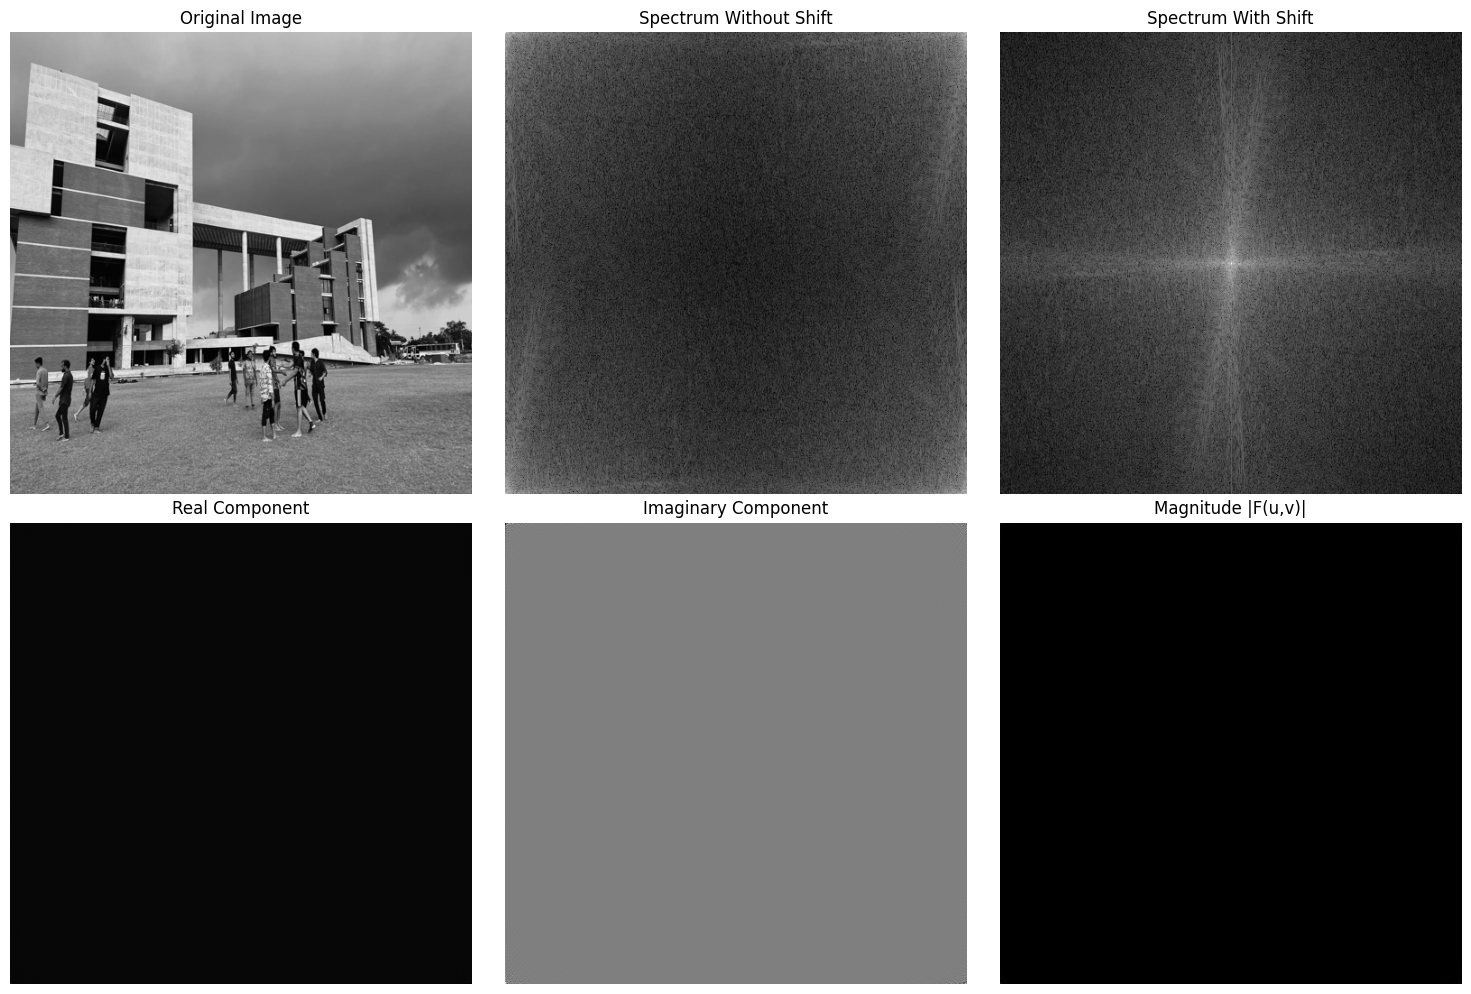

In [4]:
# Plotting
plt.figure(figsize=(15,10))

# Original Image
plt.subplot(2,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

# Without Shift
plt.subplot(2,3,2)
plt.imshow(np.log1p(magnitude), cmap='gray')
plt.title("Spectrum Without Shift")
plt.axis("off")

# With Shift
plt.subplot(2,3,3)
plt.imshow(np.log1p(magnitude_shift), cmap='gray')
plt.title("Spectrum With Shift")
plt.axis("off")

# Real Part
plt.subplot(2,3,4)
plt.imshow(real_part, cmap='gray')
plt.title("Real Component")
plt.axis("off")

# Imaginary Part
plt.subplot(2,3,5)
plt.imshow(imag_part, cmap='gray')
plt.title("Imaginary Component")
plt.axis("off")

# Magnitude
plt.subplot(2,3,6)
plt.imshow(magnitude, cmap='gray')
plt.title("Magnitude |F(u,v)|")
plt.axis("off")

plt.tight_layout()
plt.show()

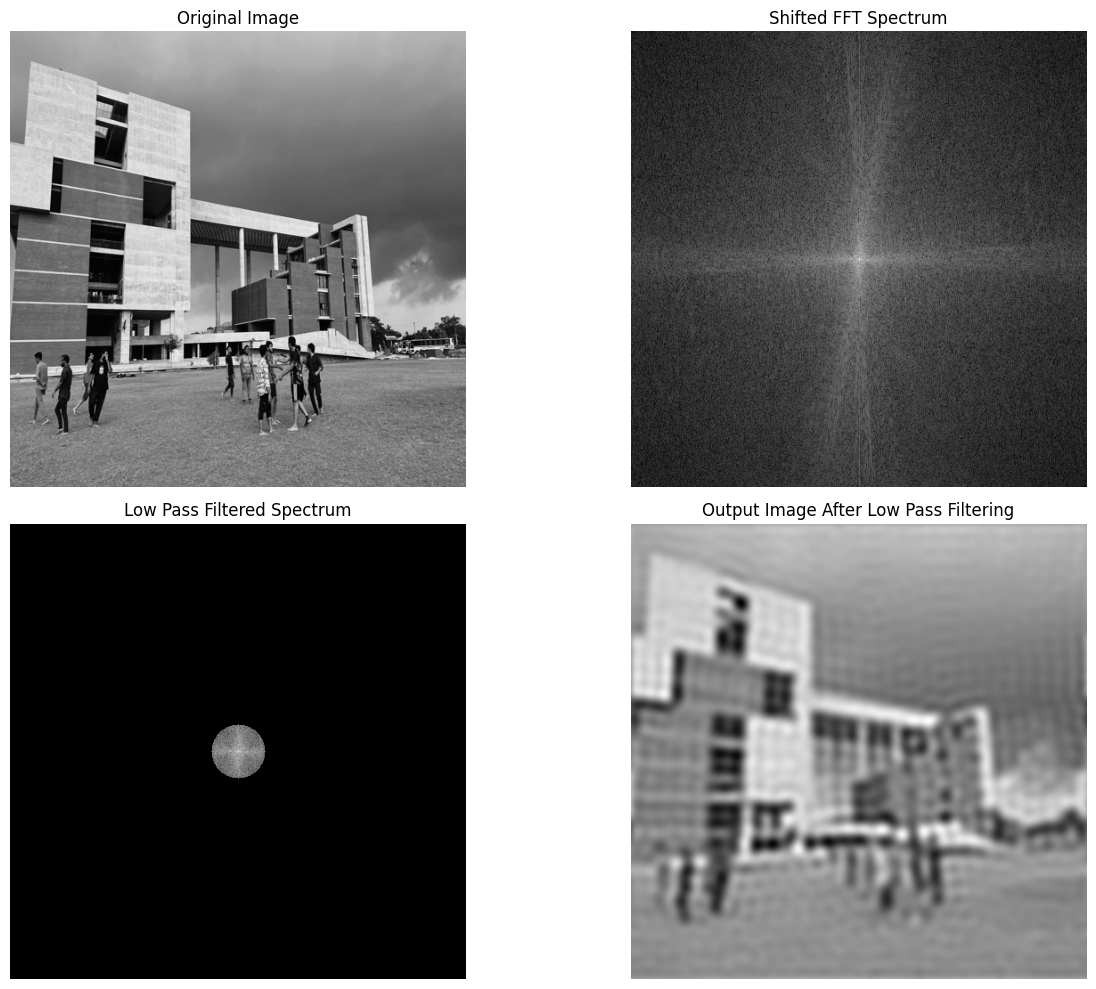

In [5]:
rows, cols = img.shape
crow, ccol = rows // 2, cols // 2

low_pass_mask = np.zeros((rows, cols), dtype=np.uint8)
radius = 30

# Circular Low Pass Filter
for i in range(rows):
    for j in range(cols):
        distance = (i - crow)**2 + (j - ccol)**2

        if distance <= radius**2:
            low_pass_mask[i, j] = 1

F_shift_low_pass = F_shift * low_pass_mask

# Magnitude of filtered spectrum
real_part_low_pass = np.real(F_shift_low_pass)
imag_part_low_pass = np.imag(F_shift_low_pass)

magnitude_low_pass = (
    real_part_low_pass**2 +
    imag_part_low_pass**2
)**0.5

# Inverse Shift
F_inverse_shift = np.fft.ifftshift(F_shift_low_pass)
# Inverse FFT
img_low_pass = np.fft.ifft2(F_inverse_shift)
# Final reconstructed image
img_low_pass = np.real(img_low_pass)

# =========================================================
# VISUALIZATION
# =========================================================

plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(np.log1p(magnitude_shift), cmap='gray')
plt.title("Shifted FFT Spectrum")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(np.log1p(magnitude_low_pass), cmap='gray')
plt.title("Low Pass Filtered Spectrum")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(img_low_pass, cmap='gray')
plt.title("Output Image After Low Pass Filtering")
plt.axis("off")

plt.tight_layout()
plt.show()

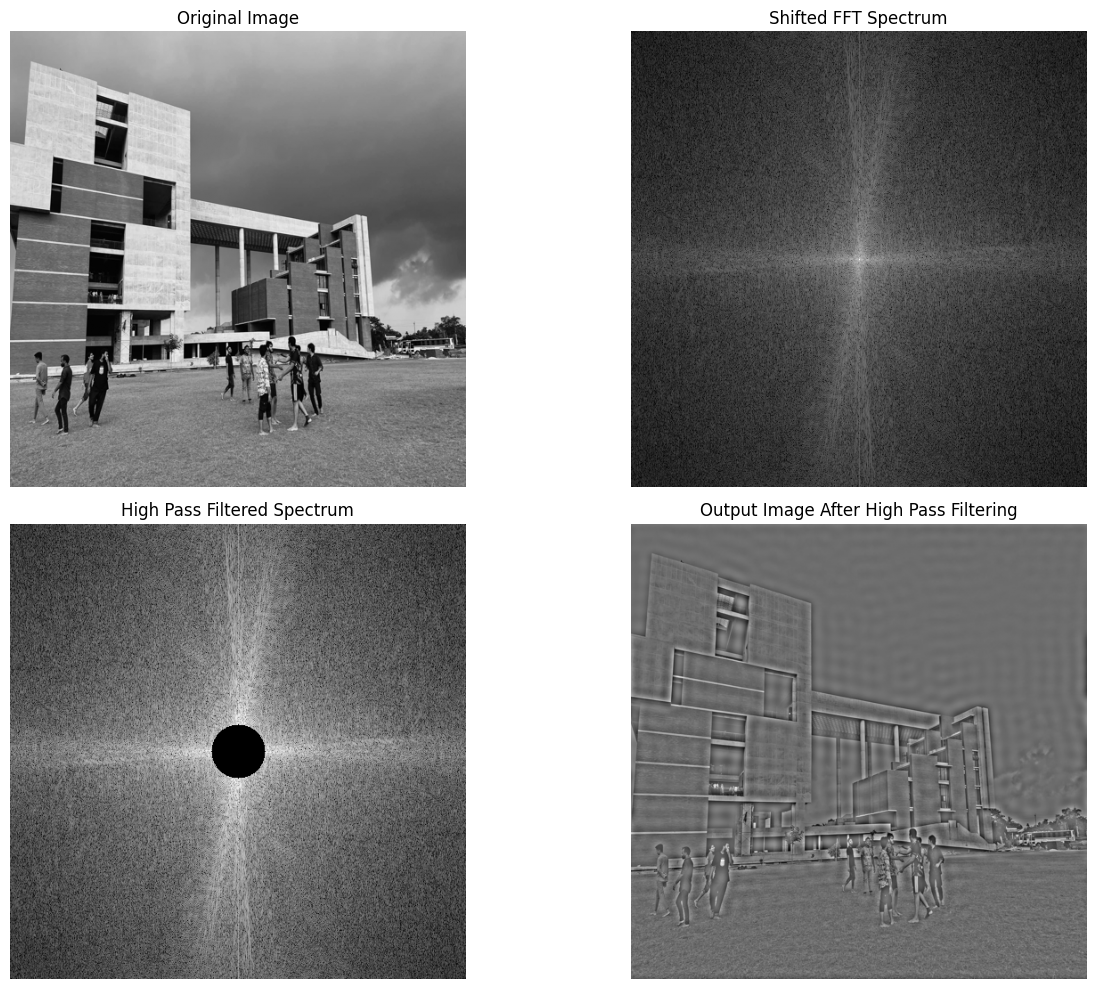

In [6]:
high_pass_mask = np.ones((rows, cols), dtype=np.uint8)
radius = 30

for i in range(rows):
    for j in range(cols):

        distance = (i - crow)**2 + (j - ccol)**2

        if distance <= radius**2:
            high_pass_mask[i, j] = 0

F_shift_high_pass = F_shift * high_pass_mask

real_part_high_pass = np.real(F_shift_high_pass)
imag_part_high_pass = np.imag(F_shift_high_pass)

magnitude_high_pass = (
    real_part_high_pass**2 +
    imag_part_high_pass**2
)**0.5

F_inverse_shift = np.fft.ifftshift(F_shift_high_pass)
img_high_pass = np.fft.ifft2(F_inverse_shift)
img_high_pass = np.real(img_high_pass)

# =========================================================
# VISUALIZATION
# =========================================================

plt.figure(figsize=(14, 10))
plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(np.log1p(magnitude_shift), cmap='gray')
plt.title("Shifted FFT Spectrum")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(np.log1p(magnitude_high_pass), cmap='gray')
plt.title("High Pass Filtered Spectrum")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(img_high_pass, cmap='gray')
plt.title("Output Image After High Pass Filtering")
plt.axis("off")

plt.tight_layout()
plt.show()

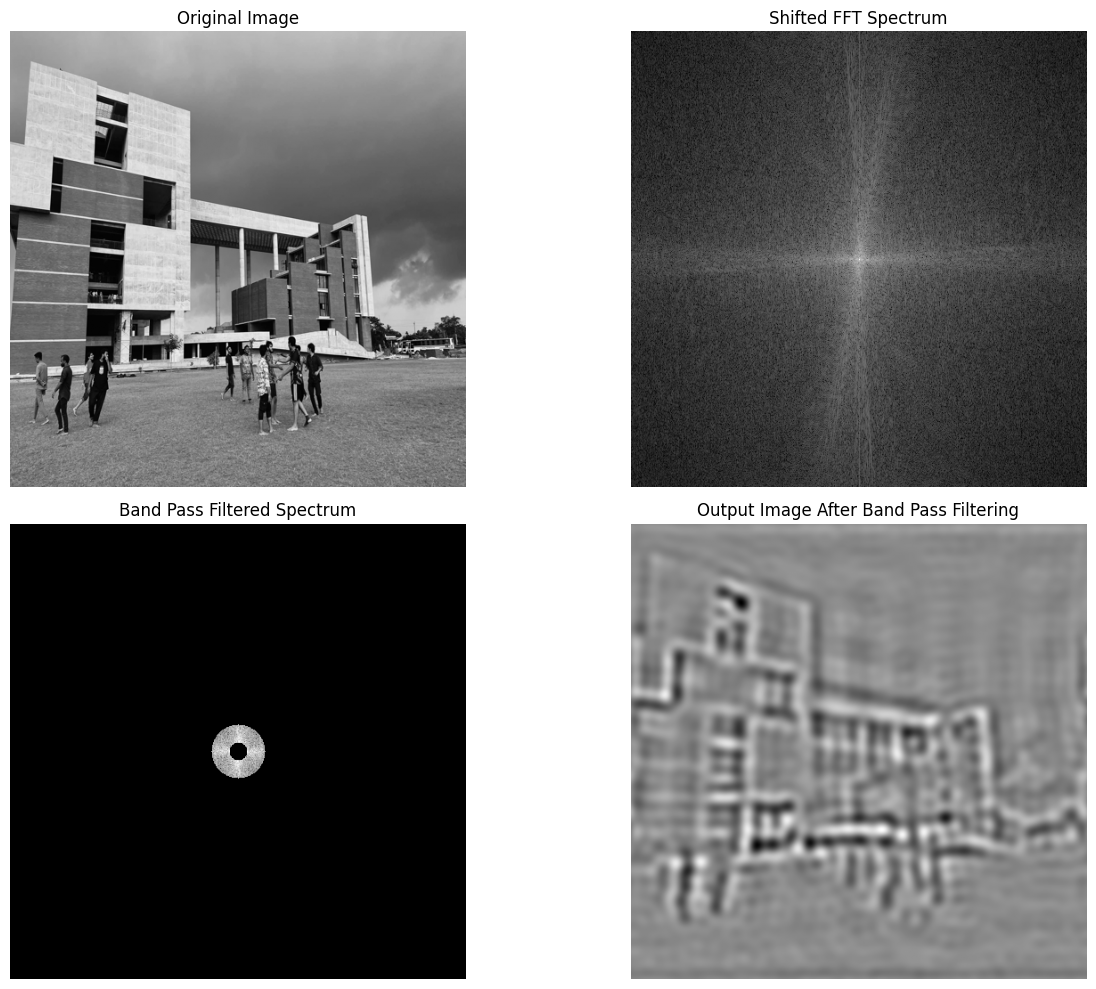

In [9]:
band_pass_mask = np.zeros((rows, cols), dtype=np.uint8)

inner_radius = 10
outer_radius = 30

for i in range(rows):
    for j in range(cols):

        distance = (i - crow)**2 + (j - ccol)**2

        if inner_radius**2 <= distance <= outer_radius**2:
            band_pass_mask[i, j] = 1

F_shift_band_pass = F_shift * band_pass_mask

real_part_band_pass = np.real(F_shift_band_pass)
imag_part_band_pass = np.imag(F_shift_band_pass)

magnitude_band_pass = (
    real_part_band_pass**2 +
    imag_part_band_pass**2
)**0.5

F_inverse_shift = np.fft.ifftshift(F_shift_band_pass)
img_band_pass = np.fft.ifft2(F_inverse_shift)
img_band_pass = np.real(img_band_pass)

# =========================================================
# VISUALIZATION
# =========================================================

plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(np.log1p(magnitude_shift), cmap='gray')
plt.title("Shifted FFT Spectrum")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(np.log1p(magnitude_band_pass), cmap='gray')
plt.title("Band Pass Filtered Spectrum")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(img_band_pass, cmap='gray')
plt.title("Output Image After Band Pass Filtering")
plt.axis("off")

plt.tight_layout()
plt.show()

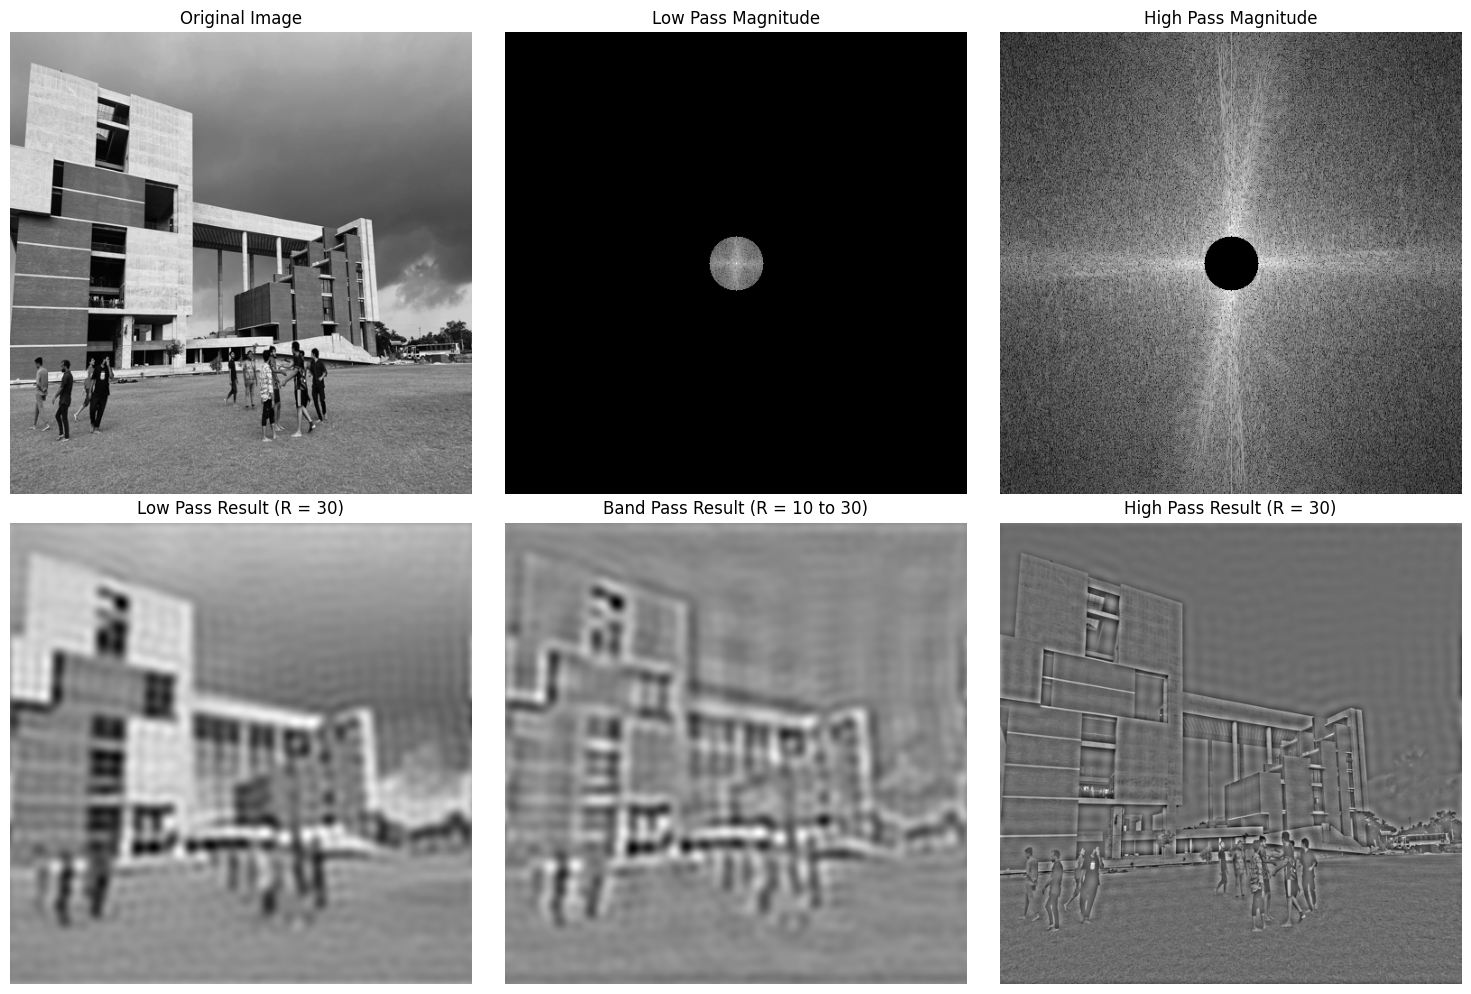

In [13]:
plt.figure(figsize=(15, 10))

# ---------------- FIRST ROW ----------------

# Original Image
plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

# Low Pass Magnitude
plt.subplot(2, 3, 2)
plt.imshow(np.log1p(magnitude_low_pass), cmap='gray')
plt.title("Low Pass Magnitude")
plt.axis("off")

# High Pass Magnitude
plt.subplot(2, 3, 3)
plt.imshow(np.log1p(magnitude_high_pass), cmap='gray')
plt.title("High Pass Magnitude")
plt.axis("off")

# ---------------- SECOND ROW ----------------

# Low Pass Result
plt.subplot(2, 3, 4)
plt.imshow(img_low_pass, cmap='gray')
plt.title("Low Pass Result (R = 30)")
plt.axis("off")

# Band Pass Result
plt.subplot(2, 3, 5)
plt.imshow(img_band_pass, cmap='gray')
plt.title("Band Pass Result (R = 10 to 30)")
plt.axis("off")

# High Pass Result
plt.subplot(2, 3, 6)
plt.imshow(img_high_pass, cmap='gray')
plt.title("High Pass Result (R = 30)")
plt.axis("off")

plt.tight_layout()
plt.show()